## **Predicting Heart Disease**
https://www.kaggle.com/competitions/playground-series-s6e2/data

## Heart Disease Features
-------------------------------------------------외과검사

- **Chest pain type** : 흉통 유형
- **Exercise angina** : 운동 시 협심증
-------------------------------------------------기본검사
- **BP** : 혈압
- **Cholesterol** : 콜레스테롤
- **FBS over 120** : 공복혈당 120 초과 여부
-  **EKG results** : 심전도 검사 결과
------------------------------------------------------ 정상/질환 그롭화 비교 시각화, outlier
- **Thallium** : 탈륨 검사 결과 (**)
- **Fluro** : 형광투시 검사 결과
- **Number of vessels** : 혈관 개수

- **Max HR** : 최대 심박수
- **ST depression** : ST 분절 하강
- **Slope of ST** : ST 분절 기울기
----------------------------------


In [1]:

from sklearn import set_config
set_config(display="text")
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split           #---- 문제답 분리

from sklearn.linear_model import LogisticRegression             #---- 분류모델(선형모델)
from sklearn.ensemble import RandomForestClassifier,  HistGradientBoostingClassifier             #---- 분류모델(트리모델)   
from sklearn.ensemble import VotingClassifier, VotingRegressor  #---- 분류모델(앙상블)  

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_curve #---- 평가 메트릭스
from sklearn.metrics import roc_auc_score, roc_curve     #---- 평가 메트릭스
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score, cross_validate  #----교차검증

from sklearn.preprocessing import LabelEncoder, OneHotEncoder                       #-----인코딩(글자->숫자변경)
from sklearn.preprocessing import StandardScaler                                  #-----정규화(스케일링)
from sklearn.decomposition import PCA                                               #-----차원축소
from sklearn.feature_selection import SelectFromModel 
import xgboost as xgb
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# **[1] Data Load**

In [2]:
train = pd.read_csv("../datas/CVD/train.csv")   
test  = pd.read_csv("../datas/CVD/test.csv") 
sub   = pd.read_csv("../datas/CVD/sample_submission.csv")

In [3]:
traincp = train.copy()
traincp.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
train.shape, test.shape, sub.shape

((630000, 15), (270000, 14), (270000, 2))

* 소문자로 변경

In [5]:
train.columns = train.columns.str.lower()
test.columns  = test.columns.str.lower()
sub.columns  = sub.columns.str.lower()

In [6]:
train.head()

,id,age,sex,chest pain type,bp,cholesterol,fbs over 120,ekg results,max hr,exercise angina,st depression,slope of st,number of vessels fluro,thallium,heart disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


* 인코딩

In [7]:
train['heart disease'] = train['heart disease'].map({"Absence": 0, "Presence": 1})

In [8]:
test.head()

,id,age,sex,chest pain type,bp,cholesterol,fbs over 120,ekg results,max hr,exercise angina,st depression,slope of st,number of vessels fluro,thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [9]:
sub.head()

,id,heart disease
0,630000,0
1,630001,0
2,630002,0
3,630003,0
4,630004,0


* Remove ID (X)

In [10]:
#train = train.drop(columns='id')
#test = test.drop(columns='id')
#sub = sub.drop(columns='id')

In [11]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   age                      630000 non-null  int64  
 2   sex                      630000 non-null  int64  
 3   chest pain type          630000 non-null  int64  
 4   bp                       630000 non-null  int64  
 5   cholesterol              630000 non-null  int64  
 6   fbs over 120             630000 non-null  int64  
 7   ekg results              630000 non-null  int64  
 8   max hr                   630000 non-null  int64  
 9   exercise angina          630000 non-null  int64  
 10  st depression            630000 non-null  float64
 11  slope of st              630000 non-null  int64  
 12  number of vessels fluro  630000 non-null  int64  
 13  thallium                 630000 non-null  int64  
 14  heart disease  

In [12]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   age                      270000 non-null  int64  
 2   sex                      270000 non-null  int64  
 3   chest pain type          270000 non-null  int64  
 4   bp                       270000 non-null  int64  
 5   cholesterol              270000 non-null  int64  
 6   fbs over 120             270000 non-null  int64  
 7   ekg results              270000 non-null  int64  
 8   max hr                   270000 non-null  int64  
 9   exercise angina          270000 non-null  int64  
 10  st depression            270000 non-null  float64
 11  slope of st              270000 non-null  int64  
 12  number of vessels fluro  270000 non-null  int64  
 13  thallium                 270000 non-null  int64  
dtypes: float64(1), 

# **[2] 공통함수**

In [13]:
def myscore222(train, model=None, MY_TARGET="heart disease"):
    
    X = train.drop(columns=[MY_TARGET])
    y = train[MY_TARGET]

    X_train7, X_test3, y_train7, y_test3 = train_test_split(
        X, y,
        test_size=0.2,
        random_state=1234,
        shuffle=True,
        stratify=y
    )

    scaler = StandardScaler()

    X_train7 = scaler.fit_transform(X_train7)
    X_test3 = scaler.transform(X_test3)

    if model is None:
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=1234
        )

    print("Model:", model.__class__.__name__)

    model.fit(X_train7, y_train7)

    pred = model.predict(X_test3)
    pred_proba = model.predict_proba(X_test3)[:, 1]

    acc = accuracy_score(y_test3, pred)
    f1 = f1_score(y_test3, pred)
    precision = precision_score(y_test3, pred)
    recall = recall_score(y_test3, pred)
    auc = roc_auc_score(y_test3, pred_proba)

    print(
        f"acc : {acc:.4f}  "
        f"f1 : {f1:.4f}  "
        f"precision : {precision:.4f}  "
        f"recall : {recall:.4f}  "
        f"auc : {auc:.4f}"
    )

    cm = confusion_matrix(y_test3, pred)
    print(cm)

    return model, scaler

# **[3] EDA(Exploratory Data Analysis)**

* 정밀 검사(특수 몇 기능 검사)

## hist() : 데이터 분포도(왜도,첨도,정규분포)

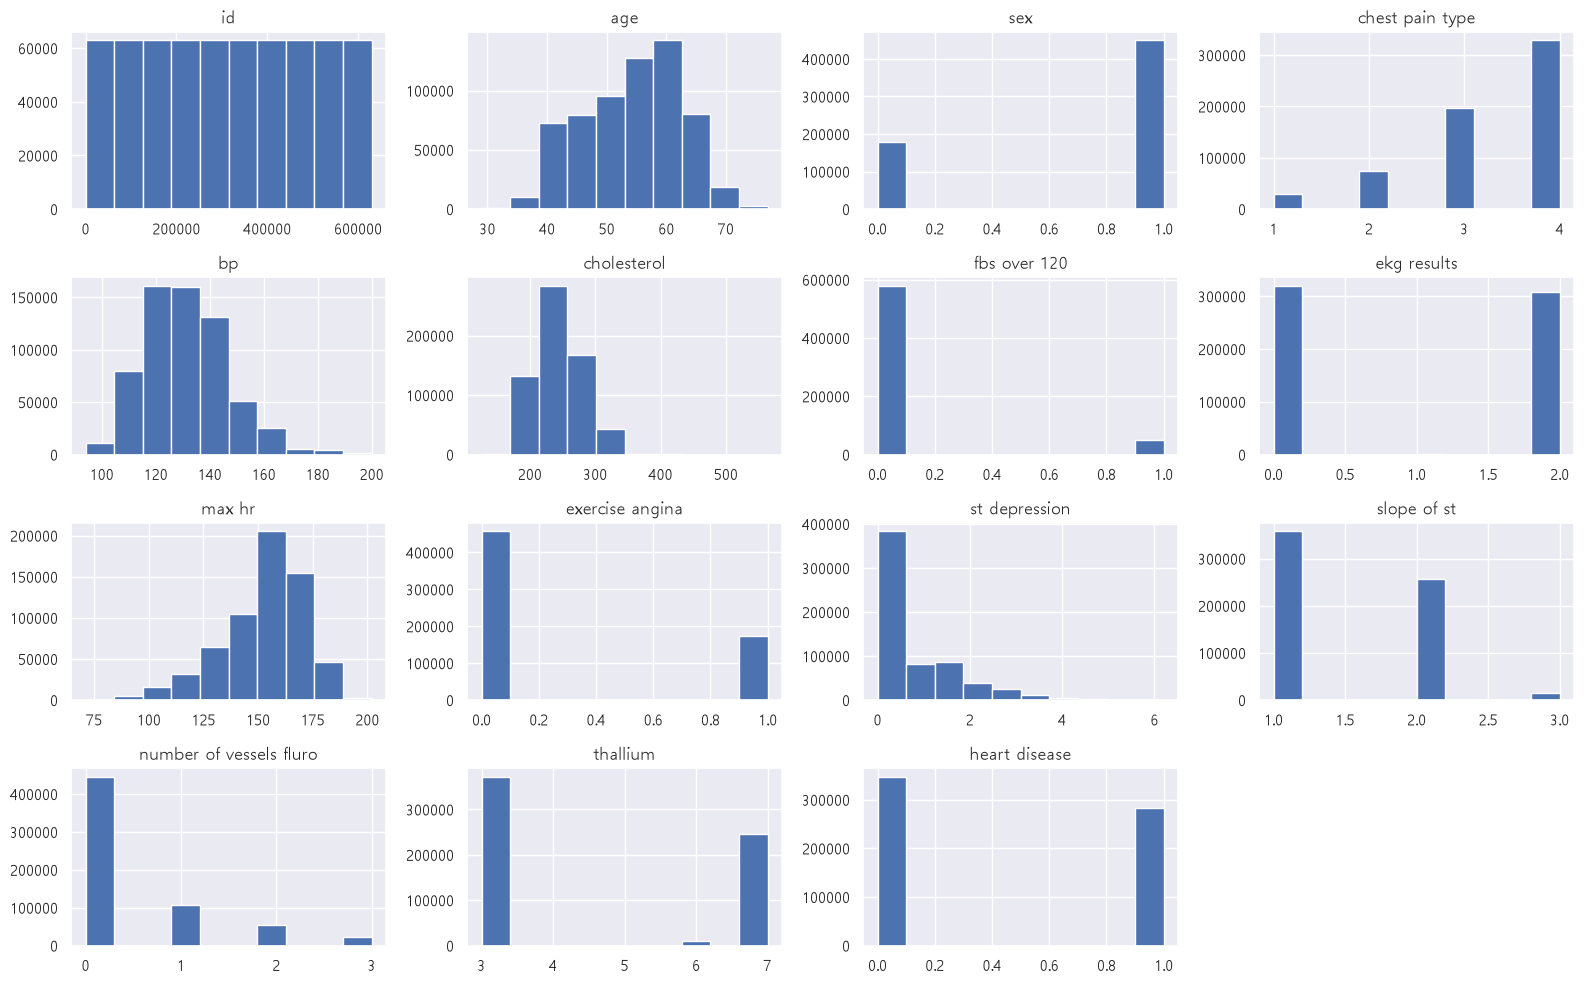

In [14]:
train.hist(figsize=(16,10))
plt.tight_layout()
plt.show()

| 지표 | 발생할 수 없는 값 |
|---|---|
| **Chest pain type** | **1~4 이외의 값** |
| **BP** | **≤ 0** |
| **Cholesterol** | **≤ 0** |
| **FBS over 120** | **0, 1 이외의 값** |
| **EKG results** | **0~2 이외의 값** |
| **Max HR** | **≤ 0** |
| **Exercise angina** | **0, 1 이외의 값** |
| **ST depression** | **< 0** *(음수 값을 허용하지 않는 경우)* |
| **Slope of ST** | **1~3 이외의 값** |
| **Number of vessels** | **0~3 이외의 값** |

## 결측여부

In [15]:
train.isna().sum()

id                         0
age                        0
sex                        0
chest pain type            0
bp                         0
cholesterol                0
fbs over 120               0
ekg results                0
max hr                     0
exercise angina            0
st depression              0
slope of st                0
number of vessels fluro    0
thallium                   0
heart disease              0
dtype: int64

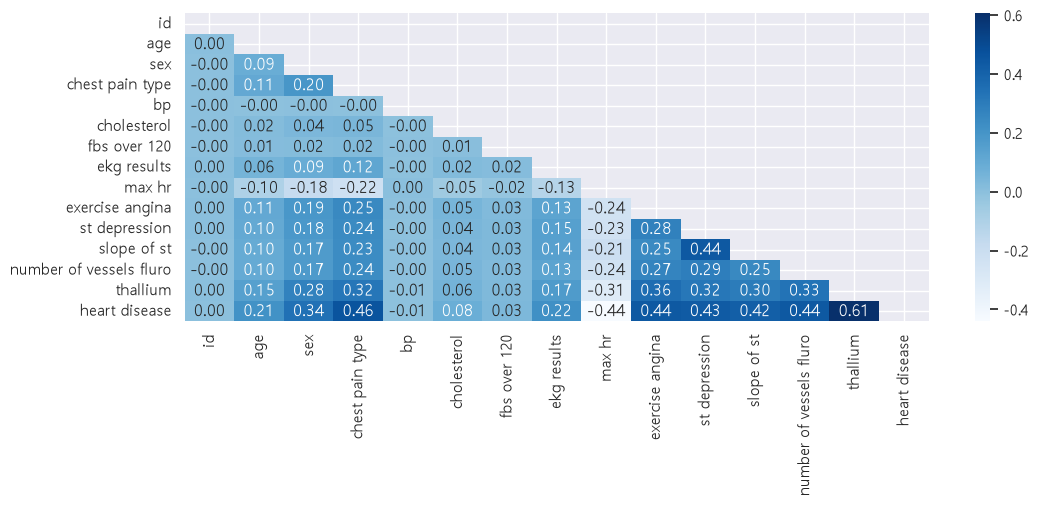

In [16]:
plt.figure(figsize=(12, 4))
# 위쪽 삼각형 가리기
mask = np.triu(np.ones_like(train.corr(), dtype=bool))
sns.heatmap(train.corr(method='pearson'), annot=True, fmt=".2f", cmap="Blues", mask=mask)
plt.show()

In [17]:
# 타깃 분포
train['heart disease'].value_counts()

heart disease
0    347546
1    282454
Name: count, dtype: int64

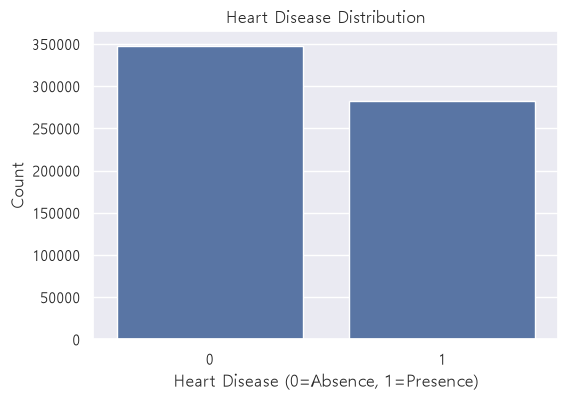

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(data=train, x='heart disease')

plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease (0=Absence, 1=Presence)')
plt.ylabel('Count')
plt.show()

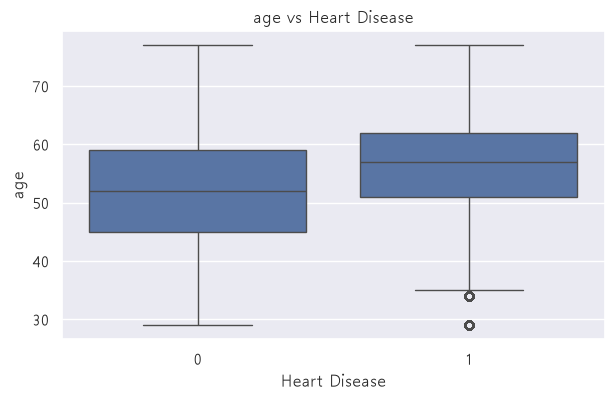

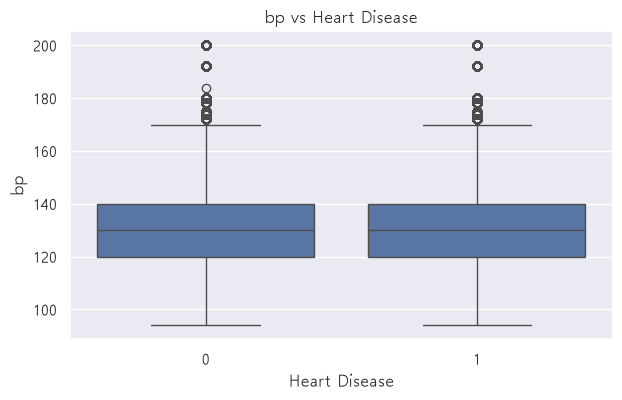

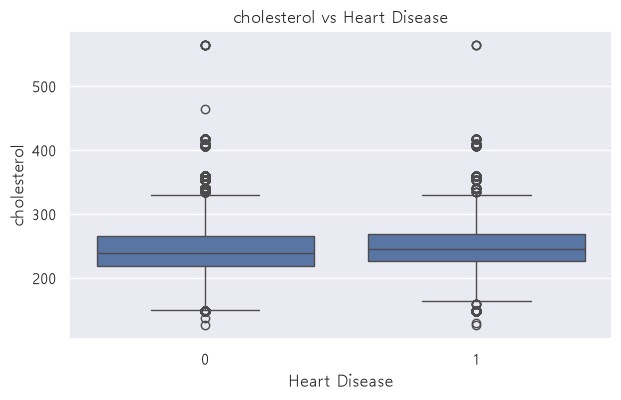

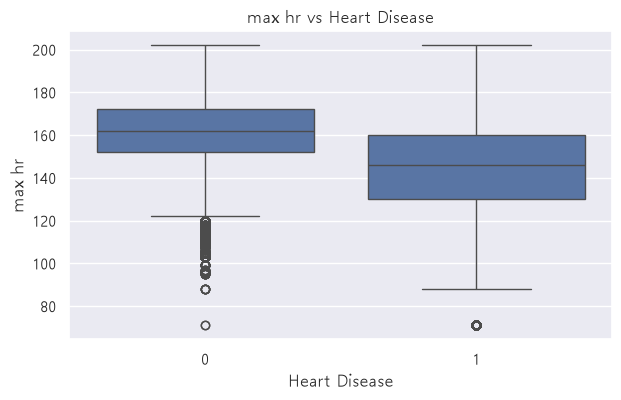

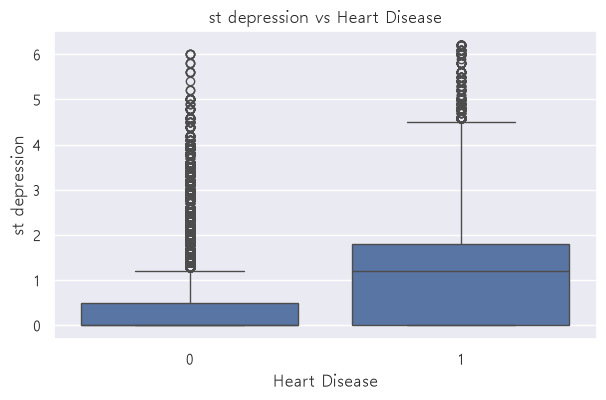

In [19]:
continuous_cols = [
    'age',
    'bp',
    'cholesterol',
    'max hr',
    'st depression'
]

for col in continuous_cols:
    plt.figure(figsize=(7,4))
    
    sns.boxplot(data=train, x='heart disease', y=col)
    
    plt.title(f'{col} vs Heart Disease')
    plt.xlabel('Heart Disease')
    plt.ylabel(col)
    plt.show()

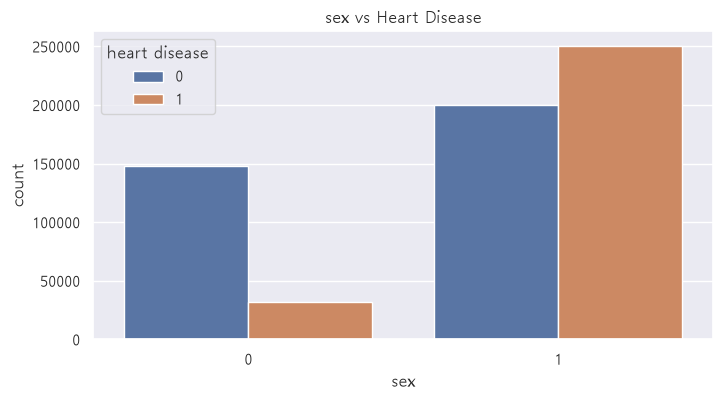

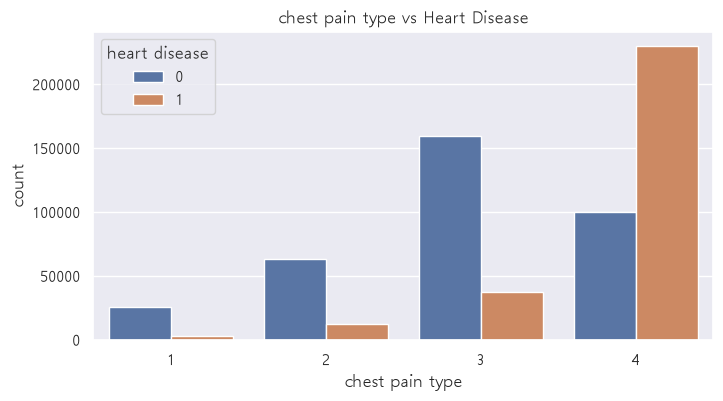

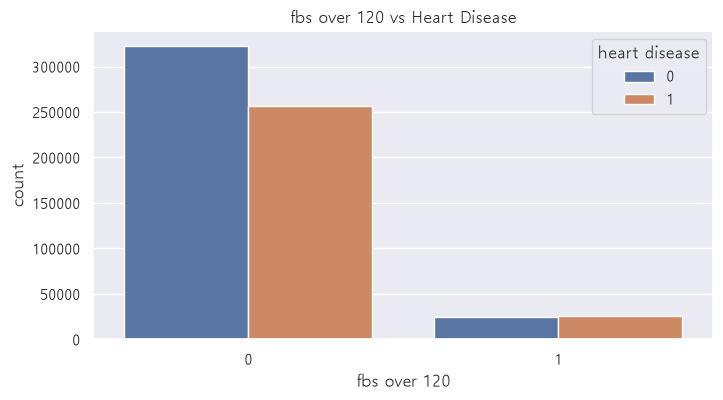

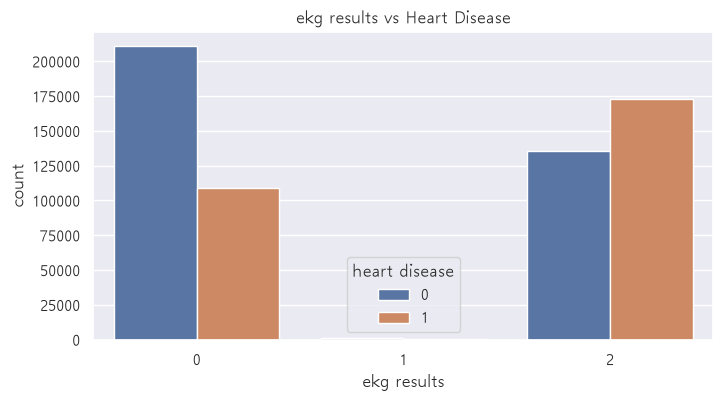

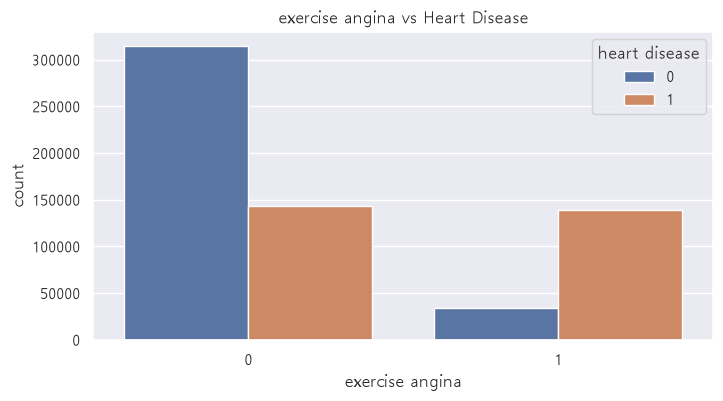

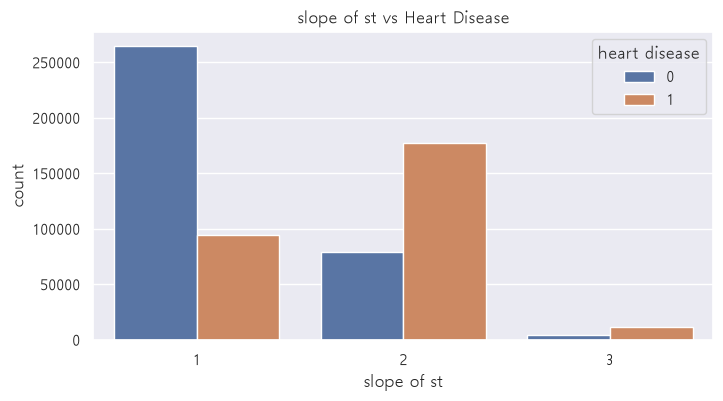

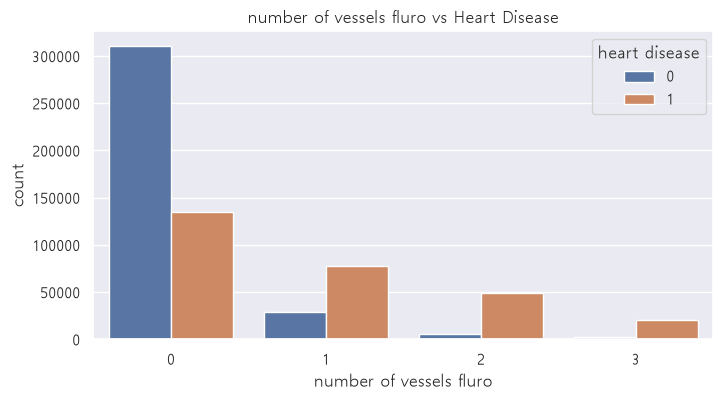

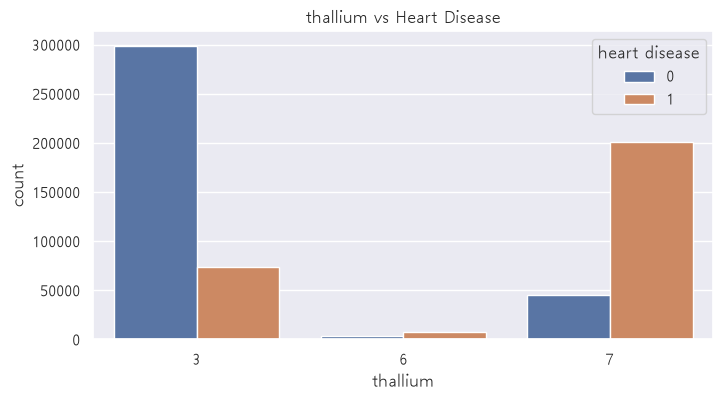

In [20]:
categorical_cols = [
    'sex',
    'chest pain type',
    'fbs over 120',
    'ekg results',
    'exercise angina',
    'slope of st',
    'number of vessels fluro',
    'thallium'
]

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    
    sns.countplot(
        data=train,
        x=col,
        hue='heart disease'
    )
    
    plt.title(f'{col} vs Heart Disease')
    plt.show()

In [21]:
train.groupby('heart disease')[continuous_cols].mean().T

heart disease,0,1
age,52.558093,56.079114
bp,130.567381,130.411366
cholesterol,242.499102,248.103585
max hr,160.415105,143.467372
st depression,0.347808,1.169104


In [22]:
train.groupby('heart disease')[continuous_cols].agg(
    ['mean', 'median', 'std']
)

age                           bp                    \
                    mean median       std        mean median        std   
heart disease                                                             
0              52.558093   52.0  8.304120  130.567381  130.0  15.135647   
1              56.079114   57.0  7.768723  130.411366  130.0  14.776321   

              cholesterol                        max hr                    \
                     mean median        std        mean median        std   
heart disease                                                               
0              242.499102  239.0  34.080064  160.415105  162.0  14.740398   
1              248.103585  246.0  32.922645  143.467372  146.0  19.722854   

              st depression                   
                       mean median       std  
heart disease                                 
0                  0.347808    0.0  0.634996  
1                  1.169104    1.2  1.066893

In [23]:
for col in categorical_cols:
    print(f'\n===== {col} =====')
    print(
        train.groupby(col)['heart disease']
        .mean()
        .sort_values(ascending=False)
    )


===== sex =====
sex
1    0.555933
0    0.178764
Name: heart disease, dtype: float64

===== chest pain type =====
chest pain type
4    0.697478
3    0.190665
2    0.162181
1    0.108069
Name: heart disease, dtype: float64

===== fbs over 120 =====
fbs over 120
1    0.504961
0    0.443417
Name: heart disease, dtype: float64

===== ekg results =====
ekg results
2    0.559560
1    0.360061
0    0.341498
Name: heart disease, dtype: float64

===== exercise angina =====
exercise angina
1    0.806288
0    0.313433
Name: heart disease, dtype: float64

===== slope of st =====
slope of st
3    0.721082
2    0.692067
1    0.262257
Name: heart disease, dtype: float64

===== number of vessels fluro =====
number of vessels fluro
3    0.899549
2    0.897078
1    0.729346
0    0.303132
Name: heart disease, dtype: float64

===== thallium =====
thallium
7    0.815391
6    0.686394
3    0.198049
Name: heart disease, dtype: float64


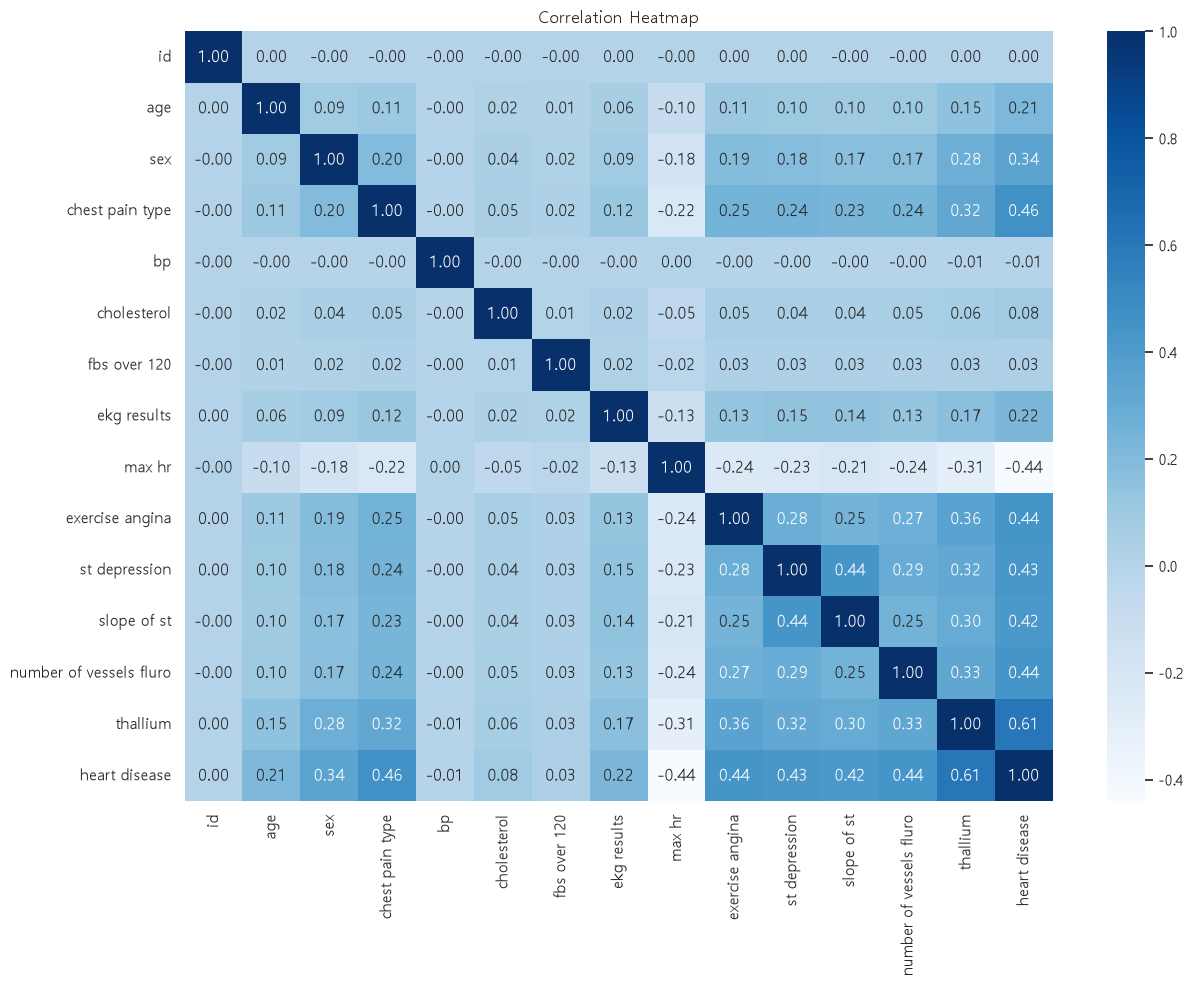

In [24]:
plt.figure(figsize=(14,10))

corr = train.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title('Correlation Heatmap')
plt.show()

# **[4]점수**

## **1차 점수:0.9476**

In [25]:
myscore222(train)

Model: RandomForestClassifier
acc : 0.8814  f1 : 0.8665  precision : 0.8749  recall : 0.8582  auc : 0.9476
[[62579  6930]
 [ 8008 48483]]


(RandomForestClassifier(random_state=1234), StandardScaler())

## **2차 점수: 0.9498**(연속형)

In [26]:
 myscore222(train,model=LogisticRegression())

Model: LogisticRegression
acc : 0.8826  f1 : 0.8671  precision : 0.8801  recall : 0.8545  auc : 0.9498
[[62933  6576]
 [ 8218 48273]]


(LogisticRegression(), StandardScaler())

## **3차 점수: 0.9537**

In [27]:
myscore222(train,model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
))


Model: XGBClassifier
acc : 0.8871  f1 : 0.8728  precision : 0.8813  recall : 0.8646  auc : 0.9537
[[62928  6581]
 [ 7650 48841]]


(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.1, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=5, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=100, n_jobs=-1,
               num_parallel_tree=None, ...),
 StandardScaler())

In [28]:
model, scaler = myscore222(train,model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
))
X_test = scaler.transform(test)
pred_proba = model.predict_proba(X_test)[:, 1]
sub = pd.DataFrame({
    'id': test['id'],
    'heart disease': pred_proba
})
sub.to_csv('sub2.csv', index=False)
print(sub.head())

Model: XGBClassifier
acc : 0.8871  f1 : 0.8728  precision : 0.8813  recall : 0.8646  auc : 0.9537
[[62928  6581]
 [ 7650 48841]]
       id  heart disease
0  630000       0.928992
1  630001       0.008465
2  630002       0.980001
3  630003       0.006114
4  630004       0.226645


## **4차 점수 :  0.9542**

In [ ]:
myscore222(train, model =(HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=1234
    )))

Model: HistGradientBoostingClassifier


In [ ]:
model, scaler = myscore222(train,model = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=1234
))
X_test = scaler.transform(test)
pred_proba = model.predict_proba(X_test)[:, 1]
sub = pd.DataFrame({
    'id': test['id'],
    'heart disease': pred_proba
})
sub.to_csv('sub3.csv', index=False)
print(sub.head())

## **5차 점수 : 0.9545**

In [ ]:
lgb = LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=1234,
    n_jobs=-1,
    verbosity=-1
)

xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.5,
    eval_metric="logloss",
    random_state=1234,
    n_jobs=-1
)

model = VotingClassifier(
    estimators=[
        ("lgb", lgb),
        ("xgb", xgb)
    ],
    voting="soft",
    weights=[1, 1]
)

model, scaler = myscore222(
    train,
    model=model,
    MY_TARGET="heart disease"
)
X_test = scaler.transform(test)
pred_proba = model.predict_proba(X_test)[:, 1]
sub = pd.DataFrame({
    'id': test['id'],
    'heart disease': pred_proba
})
sub.to_csv('sub4.csv', index=False)
print(sub.head())

In [ ]:
myscore222(train, model = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=100
))